# Bottle Mouth / Head Detection in Video — Method Comparison + Model Downloader

This notebook compares different ways to detect the **head/mouth of bottles without caps** in a video and export the **pixel location** of each detected bottle mouth.

It includes:

1. **OpenCV Hough Circle Detection**
2. **OpenCV Contour / Threshold Detection**
3. **OpenCV Template Matching**
4. **YOLO Detection / Tracking**
5. **MediaPipe Object Detector**

It also includes a **model downloader section**:

- Download a pretrained YOLO model for testing the detection pipeline.
- Download a MediaPipe sample EfficientDet-Lite0 `.tflite` model for testing the MediaPipe pipeline.
- Keep space for your future **custom YOLO bottle-mouth model**.

Important:

A pretrained model will usually detect the **whole bottle**, not the exact **bottle mouth without cap**.  
For the final accurate system, you should train a custom YOLO model with one class:

```text
bottle_mouth
```

## Recommended project structure

```text
project/
  bottle_mouth_detection_comparison_with_models.ipynb
  requirements.txt
  .gitignore

  data/
    input_video.mp4
    template_bottle_mouth.png          # optional
    ground_truth.csv                   # optional

  models/
    yolo_pretrained_test.pt            # downloaded automatically
    yolo_bottle_mouth.pt               # your custom trained model
    mediapipe_sample_detector.tflite   # downloaded automatically

  outputs/
```

## 1. Install requirements

Run this in terminal:

```bash
pip install -r requirements.txt
```

Or from inside the notebook:

```python
%pip install -r requirements.txt
```

In [1]:
from pathlib import Path
import os
import time
import math
import json
import shutil
import urllib.request
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("OpenCV:", cv2.__version__)

OpenCV: 4.13.0


## 2. Paths and configuration

Change `VIDEO_PATH` to your own video.

The notebook will automatically create:

```text
models/
outputs/
```

In [2]:
# -----------------------------
# Main paths
# -----------------------------
VIDEO_PATH = Path("../data/1.avi")

DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional inputs
TEMPLATE_IMAGE_PATH = DATA_DIR / "temp.png"
GROUND_TRUTH_CSV = DATA_DIR / "ground_truth.csv"

# Downloaded / custom model paths
YOLO_PRETRAINED_TEST_PATH = MODELS_DIR / "yolo_pretrained_test.pt"
YOLO_CUSTOM_BOTTLE_MOUTH_PATH = MODELS_DIR / "yolo_bottle_mouth.pt"
MEDIAPIPE_SAMPLE_MODEL_PATH = MODELS_DIR / "mediapipe_sample_detector.tflite"

# Runtime controls
MAX_FRAMES = 300              # None = full video
SAMPLE_EVERY_N_FRAMES = 1     # 1 = every frame
DISPLAY_WIDTH = 900

# Accuracy evaluation
MATCH_DISTANCE_PX = 25

print("Video:", VIDEO_PATH)
print("Models dir:", MODELS_DIR.resolve())
print("Output dir:", OUTPUT_DIR.resolve())

Video: ..\data\1.avi
Models dir: C:\Users\Matin\source\repos\Bottle_Head_Detection\models
Output dir: C:\Users\Matin\source\repos\Bottle_Head_Detection\outputs


# 3. Download models

## Important

The downloaded YOLO model is only for testing the pipeline.  
It is trained on COCO classes and may detect the **whole bottle**, not the **bottle mouth**.

For final work, train your own model and place it here:

```text
models/yolo_bottle_mouth.pt
```

The notebook will use your custom model automatically if it exists. Otherwise, it will fall back to the downloaded pretrained test model.

In [ ]:
# You can change this to another Ultralytics model name.
# Stable example:
YOLO_PRETRAINED_MODEL_NAME = "yolo11n.pt"

# MediaPipe sample detector model.
# This is a general COCO object detector, not a custom bottle-mouth model.
MEDIAPIPE_SAMPLE_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "object_detector/efficientdet_lite0/int8/1/efficientdet_lite0.tflite"
)


def download_file(url: str, destination: Path, overwrite: bool = False):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and not overwrite:
        print(f"Already exists: {destination}")
        return destination

    print(f"Downloading:\n  {url}\n→ {destination}")
    urllib.request.urlretrieve(url, destination)
    print(f"Saved: {destination} ({destination.stat().st_size / 1024 / 1024:.2f} MB)")
    return destination


def download_yolo_pretrained(model_name: str = YOLO_PRETRAINED_MODEL_NAME,
                             destination: Path = YOLO_PRETRAINED_TEST_PATH,
                             overwrite: bool = False):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and not overwrite:
        print(f"Already exists: {destination}")
        return destination

    try:
        from ultralytics import YOLO
    except ImportError as exc:
        raise ImportError("Install ultralytics first: pip install ultralytics") from exc

    print(f"Loading YOLO model: {model_name}")
    print("Ultralytics will download it automatically if it is not already available.")

    model = YOLO(model_name)

    # Usually Ultralytics downloads to the working directory, but this fallback
    # handles different package/cache behavior.
    candidates = [
        Path(model_name),
        Path(getattr(model, "ckpt_path", "")) if getattr(model, "ckpt_path", None) else None,
        Path(getattr(model, "model_name", "")) if getattr(model, "model_name", None) else None,
    ]
    candidates = [p for p in candidates if p is not None and str(p) and p.exists()]

    if not candidates:
        # Some versions may keep the checkpoint internally. In that case,
        # save a minimal note and let YOLO(model_name) be used directly.
        print("Could not find a local .pt file after loading.")
        print("The notebook can still use YOLO(model_name) directly.")
        return None

    source = candidates[0]
    shutil.copy2(source, destination)
    print(f"Copied YOLO model:\n  {source}\n→ {destination}")
    return destination


# Download YOLO test model
try:
    download_yolo_pretrained(destination=MODELS_DIR)
except Exception as e:
    print("YOLO model download failed:")
    print(e)

# Download MediaPipe sample model
try:
    download_file(MEDIAPIPE_SAMPLE_MODEL_URL, MEDIAPIPE_SAMPLE_MODEL_PATH)
except Exception as e:
    print("MediaPipe sample model download failed:")
    print(e)

Already exists: ..\models\yolo_pretrained_test.pt
Already exists: ..\models\mediapipe_sample_detector.tflite


## 3.1 Decide which YOLO model to use

Priority:

1. Use your custom model if this file exists:

```text
models/yolo_bottle_mouth.pt
```

2. Otherwise use the downloaded pretrained test model:

```text
models/yolo_pretrained_test.pt
```

3. Otherwise use the model name directly, for example:

```text
yolo11n.pt
```

In [4]:
def choose_yolo_model_path():
    if YOLO_CUSTOM_BOTTLE_MOUTH_PATH.exists():
        print("Using custom YOLO bottle-mouth model:")
        print(YOLO_CUSTOM_BOTTLE_MOUTH_PATH)
        return YOLO_CUSTOM_BOTTLE_MOUTH_PATH, "custom_bottle_mouth"

    if YOLO_PRETRAINED_TEST_PATH.exists():
        print("Using downloaded pretrained YOLO model for testing only:")
        print(YOLO_PRETRAINED_TEST_PATH)
        return YOLO_PRETRAINED_TEST_PATH, "pretrained_test"

    print("No local YOLO model found. Will use Ultralytics model name directly:")
    print(YOLO_PRETRAINED_MODEL_NAME)
    return YOLO_PRETRAINED_MODEL_NAME, "pretrained_name"


YOLO_MODEL_SOURCE, YOLO_MODEL_KIND = choose_yolo_model_path()

print("YOLO_MODEL_SOURCE:", YOLO_MODEL_SOURCE)
print("YOLO_MODEL_KIND:", YOLO_MODEL_KIND)

Using downloaded pretrained YOLO model for testing only:
..\models\yolo_pretrained_test.pt
YOLO_MODEL_SOURCE: ..\models\yolo_pretrained_test.pt
YOLO_MODEL_KIND: pretrained_test


# 4. Video helper functions

In [5]:
def get_video_info(video_path: Path) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")

    info = {
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()
    return info


def iter_video_frames(video_path: Path, max_frames=None, sample_every_n_frames=1):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_idx = 0
    yielded = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % sample_every_n_frames == 0:
            time_sec = frame_idx / fps if fps else np.nan
            yield frame_idx, time_sec, frame
            yielded += 1

            if max_frames is not None and yielded >= max_frames:
                break

        frame_idx += 1

    cap.release()


def get_frame_by_index(video_path: Path, target_frame_idx: int):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame_idx)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None


def resize_for_display(frame, width=900):
    h, w = frame.shape[:2]
    if w <= width:
        return frame
    scale = width / w
    return cv2.resize(frame, (int(w * scale), int(h * scale)))


def bgr_to_rgb(frame):
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def show_frame(frame, title=None, width=900):
    frame_small = resize_for_display(frame, width)
    plt.figure(figsize=(12, 7))
    plt.imshow(bgr_to_rgb(frame_small))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def draw_detections(frame, detections, color=(0, 255, 0), label_prefix=""):
    out = frame.copy()

    for det in detections:
        x = int(round(det.get("x_center", 0)))
        y = int(round(det.get("y_center", 0)))
        conf = det.get("confidence", np.nan)

        if not np.isnan(det.get("x1", np.nan)):
            x1 = int(round(det["x1"]))
            y1 = int(round(det["y1"]))
            x2 = int(round(det["x2"]))
            y2 = int(round(det["y2"]))
            cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)

        if not np.isnan(det.get("radius", np.nan)):
            r = int(round(det["radius"]))
            cv2.circle(out, (x, y), r, color, 2)

        cv2.circle(out, (x, y), 4, (0, 0, 255), -1)

        text = f"{label_prefix}({x},{y})"
        if not np.isnan(conf):
            text += f" {conf:.2f}"

        cv2.putText(out, text, (x + 5, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    return out


def detections_to_dataframe(detections):
    columns = [
        "method", "frame", "time_sec", "track_id",
        "class_id", "class_name",
        "x_center", "y_center", "radius",
        "x1", "y1", "x2", "y2",
        "confidence"
    ]
    if not detections:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(detections)

# 5. Check video

{
  "fps": 30.00003000003,
  "frame_count": 528,
  "width": 1280,
  "height": 720
}


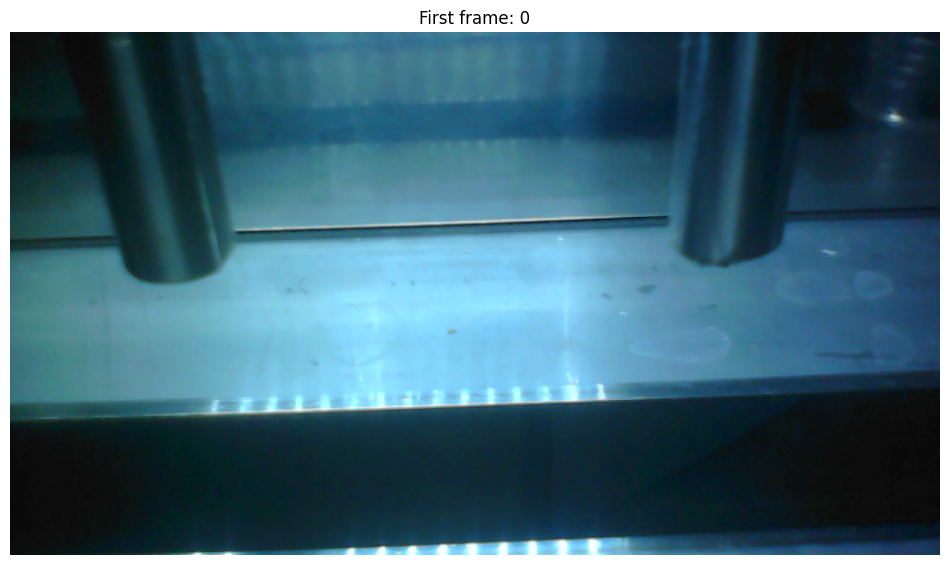

In [6]:
if VIDEO_PATH.exists():
    video_info = get_video_info(VIDEO_PATH)
    print(json.dumps(video_info, indent=2))

    first_item = next(iter_video_frames(VIDEO_PATH, max_frames=1), None)
    if first_item is not None:
        frame_idx, time_sec, first_frame = first_item
        show_frame(first_frame, title=f"First frame: {frame_idx}")
else:
    print(f"Video not found: {VIDEO_PATH}")
    print("Put your video at data/input_video.mp4 or change VIDEO_PATH above.")

# Method 1 — OpenCV Hough Circle Detection

Useful if the bottle mouth/opening appears as a circle or ellipse-like ring.

Tune:

- `minRadius`
- `maxRadius`
- `param2`
- `minDist`

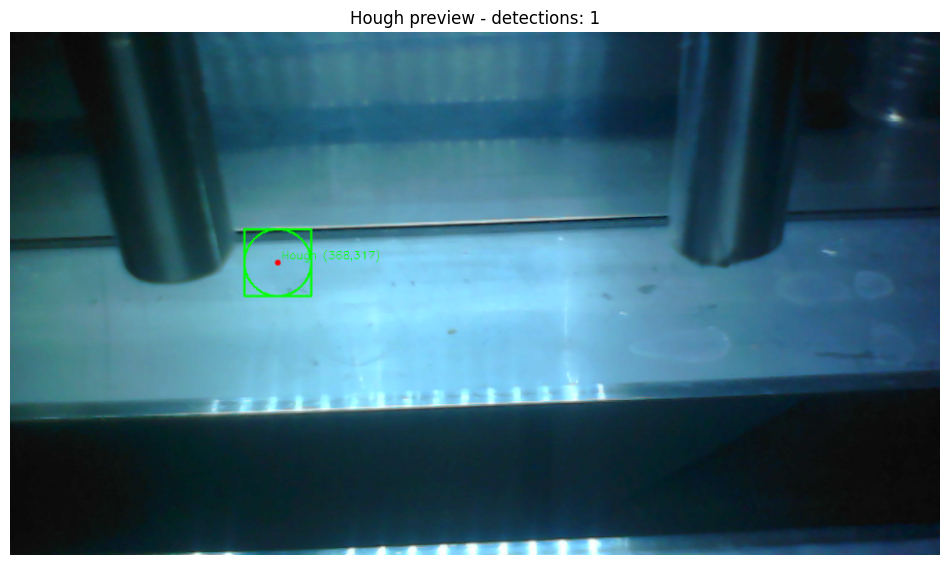

In [7]:
HOUGH_PARAMS = {
    "dp": 1.2,
    "minDist": 30,
    "param1": 80,
    "param2": 28,
    "minRadius": 5,
    "maxRadius": 60,
}


def detect_hough_bottle_mouths(frame, params=HOUGH_PARAMS):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 5)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=params["dp"],
        minDist=params["minDist"],
        param1=params["param1"],
        param2=params["param2"],
        minRadius=params["minRadius"],
        maxRadius=params["maxRadius"],
    )

    detections = []
    if circles is None:
        return detections

    circles = np.round(circles[0, :]).astype(int)

    for x, y, r in circles:
        detections.append({
            "method": "opencv_hough",
            "frame": None,
            "time_sec": None,
            "track_id": -1,
            "class_id": 0,
            "class_name": "bottle_mouth_candidate",
            "x_center": float(x),
            "y_center": float(y),
            "radius": float(r),
            "x1": float(x - r),
            "y1": float(y - r),
            "x2": float(x + r),
            "y2": float(y + r),
            "confidence": np.nan,
        })

    return detections


if VIDEO_PATH.exists():
    sample = next(iter_video_frames(VIDEO_PATH, max_frames=1), None)
    if sample:
        _, _, frame = sample
        dets = detect_hough_bottle_mouths(frame)
        preview = draw_detections(frame, dets, label_prefix="Hough ")
        show_frame(preview, title=f"Hough preview - detections: {len(dets)}")

# Method 2 — OpenCV Contour / Threshold Detection

This method can work when the bottle mouth has a strong contrast against the background.

For transparent bottles or reflective plastic, this may be unstable.

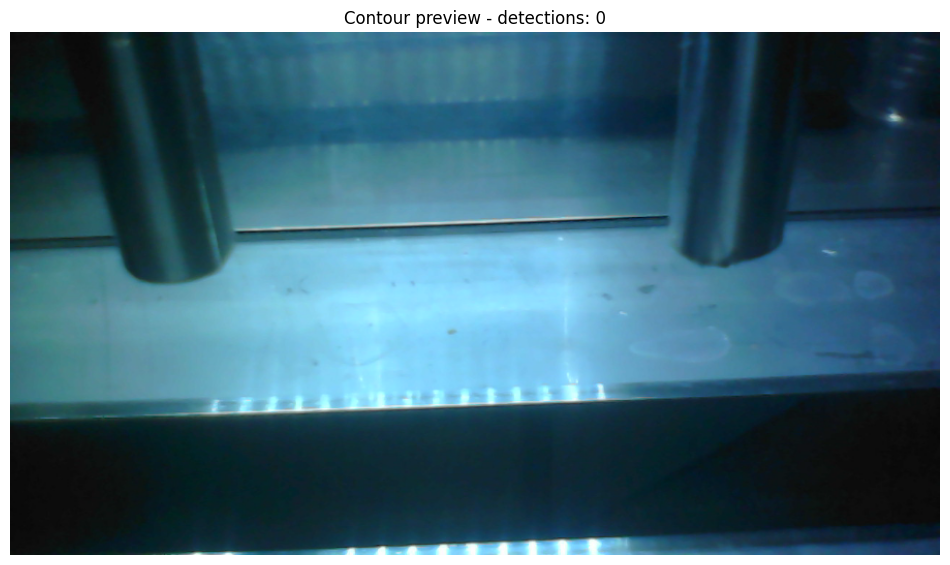

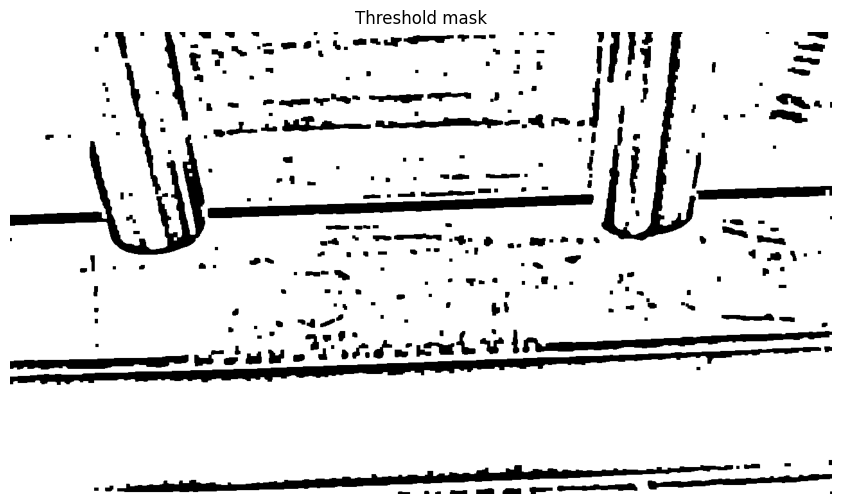

In [8]:
CONTOUR_PARAMS = {
    "min_area": 50,
    "max_area": 5000,
    "min_circularity": 0.35,
    "kernel_size": 5,
    "threshold_mode": "adaptive",  # "adaptive" or "otsu"
}


def circularity_from_contour(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    if perimeter <= 0:
        return 0
    return 4 * math.pi * area / (perimeter * perimeter)


def detect_contour_bottle_mouths(frame, params=CONTOUR_PARAMS):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    if params["threshold_mode"] == "otsu":
        _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        mask = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            31,
            2
        )

    k = params["kernel_size"]
    kernel = np.ones((k, k), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    detections = []

    for c in contours:
        area = cv2.contourArea(c)
        if area < params["min_area"] or area > params["max_area"]:
            continue

        circ = circularity_from_contour(c)
        if circ < params["min_circularity"]:
            continue

        x, y, w, h = cv2.boundingRect(c)
        (cx, cy), radius = cv2.minEnclosingCircle(c)

        detections.append({
            "method": "opencv_contour",
            "frame": None,
            "time_sec": None,
            "track_id": -1,
            "class_id": 0,
            "class_name": "bottle_mouth_candidate",
            "x_center": float(cx),
            "y_center": float(cy),
            "radius": float(radius),
            "x1": float(x),
            "y1": float(y),
            "x2": float(x + w),
            "y2": float(y + h),
            "confidence": float(circ),
        })

    return detections, mask


if VIDEO_PATH.exists():
    sample = next(iter_video_frames(VIDEO_PATH, max_frames=1), None)
    if sample:
        _, _, frame = sample
        dets, mask = detect_contour_bottle_mouths(frame)
        preview = draw_detections(frame, dets, label_prefix="Contour ")
        show_frame(preview, title=f"Contour preview - detections: {len(dets)}")

        plt.figure(figsize=(12, 6))
        plt.imshow(mask, cmap="gray")
        plt.axis("off")
        plt.title("Threshold mask")
        plt.show()

# Method 3 — Template Matching

Put a tight crop of the bottle mouth here:

```text
data/template_bottle_mouth.png
```

This method works only when scale, rotation, and viewpoint are mostly constant.

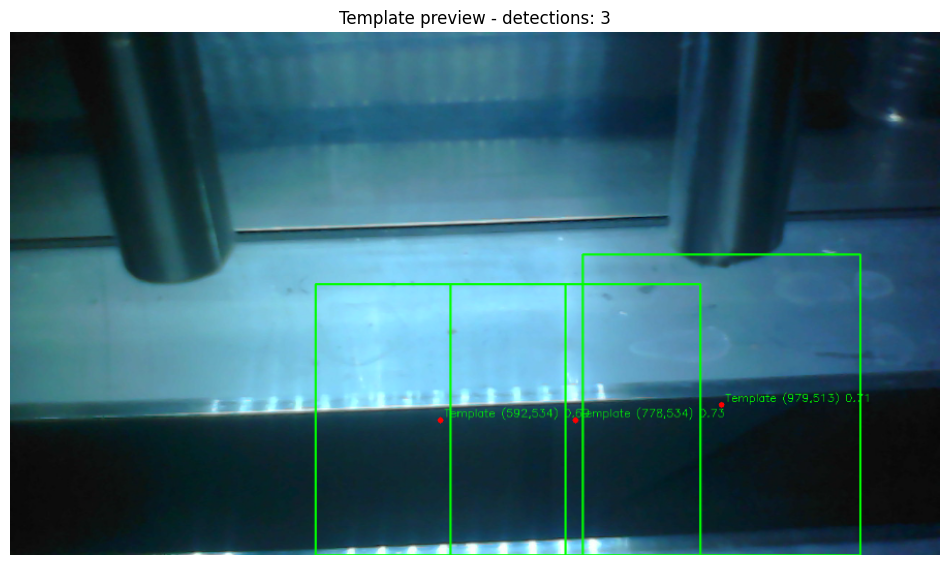

In [9]:
TEMPLATE_MATCH_PARAMS = {
    "threshold": 0.65,
    "nms_iou_threshold": 0.3,
    "scales": [0.8, 0.9, 1.0, 1.1, 1.2],
}


def nms_boxes(boxes, scores, iou_threshold=0.3):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes, dtype=float)
    scores = np.array(scores, dtype=float)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores.argsort()[::-1]
    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        inter = w * h

        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)

        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]

    return keep


def detect_template_bottle_mouths(frame, template_bgr, params=TEMPLATE_MATCH_PARAMS):
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    template_gray_orig = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2GRAY)

    boxes = []
    scores = []

    for scale in params["scales"]:
        template_gray = cv2.resize(template_gray_orig, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
        th, tw = template_gray.shape[:2]

        if th >= frame_gray.shape[0] or tw >= frame_gray.shape[1]:
            continue

        result = cv2.matchTemplate(frame_gray, template_gray, cv2.TM_CCOEFF_NORMED)
        ys, xs = np.where(result >= params["threshold"])

        for x, y in zip(xs, ys):
            score = float(result[y, x])
            boxes.append([x, y, x + tw, y + th])
            scores.append(score)

    keep = nms_boxes(boxes, scores, params["nms_iou_threshold"])

    detections = []

    for i in keep:
        x1, y1, x2, y2 = boxes[i]
        score = scores[i]
        detections.append({
            "method": "opencv_template",
            "frame": None,
            "time_sec": None,
            "track_id": -1,
            "class_id": 0,
            "class_name": "bottle_mouth_candidate",
            "x_center": float((x1 + x2) / 2),
            "y_center": float((y1 + y2) / 2),
            "radius": np.nan,
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "confidence": float(score),
        })

    return detections


if VIDEO_PATH.exists() and TEMPLATE_IMAGE_PATH.exists():
    template_bgr = cv2.imread(str(TEMPLATE_IMAGE_PATH))
    sample = next(iter_video_frames(VIDEO_PATH, max_frames=1), None)
    if sample and template_bgr is not None:
        _, _, frame = sample
        dets = detect_template_bottle_mouths(frame, template_bgr)
        preview = draw_detections(frame, dets, label_prefix="Template ")
        show_frame(preview, title=f"Template preview - detections: {len(dets)}")
else:
    print(f"Template image not found, skipping template preview: {TEMPLATE_IMAGE_PATH}")

# Method 4 — YOLO Detection / Tracking

The YOLO section supports two cases:

## Case A — pretrained test model

This is only for checking that the pipeline works.  
It may detect `bottle`, but not the exact mouth.

## Case B — custom bottle-mouth model

This is the correct final model:

```text
models/yolo_bottle_mouth.pt
```

The detector output center is:

```python
x_center = (x1 + x2) / 2
y_center = (y1 + y2) / 2
```

Pretrained model class names include:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'ke

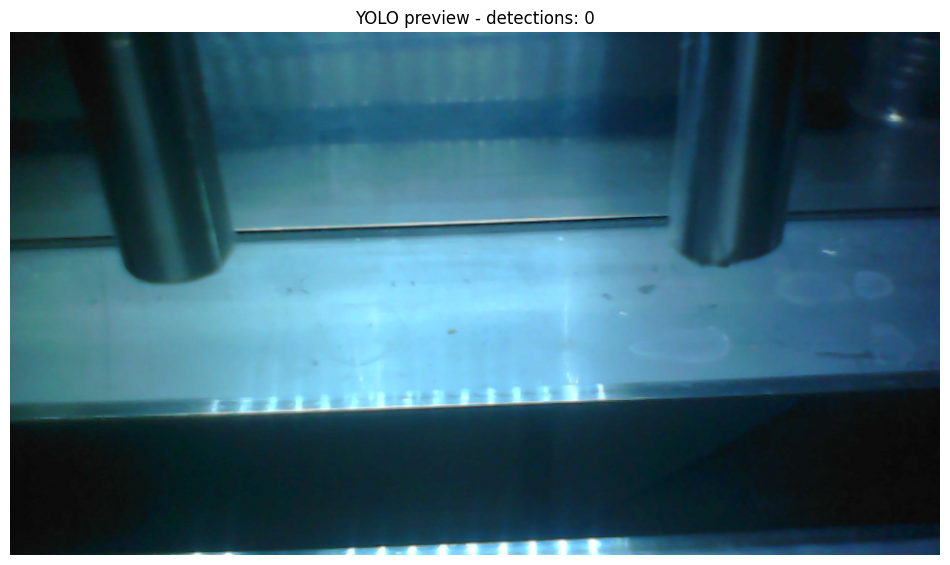

In [10]:
def load_yolo_model(model_source):
    try:
        from ultralytics import YOLO
    except ImportError:
        print("Ultralytics is not installed. Install it with: pip install ultralytics")
        return None

    return YOLO(str(model_source))


YOLO_PARAMS = {
    "conf": 0.35,
    "iou": 0.5,
    "tracker": "bytetrack.yaml",
    # For custom bottle_mouth model, keep None.
    # For pretrained COCO test model, you may set class name filter to ['bottle'] below.
    "class_name_filter": None,
}


def yolo_class_ids_from_names(model, class_names):
    if class_names is None:
        return None

    if isinstance(class_names, str):
        class_names = [class_names]

    wanted = set([name.lower() for name in class_names])
    names = getattr(model, "names", None)

    if names is None:
        return None

    matched_ids = []
    for class_id, name in names.items():
        if str(name).lower() in wanted:
            matched_ids.append(int(class_id))

    return matched_ids if matched_ids else None


def detect_yolo_bottle_mouths(frame, model, params=YOLO_PARAMS):
    if model is None:
        return []

    class_ids = yolo_class_ids_from_names(model, params.get("class_name_filter"))

    results = model.track(
        frame,
        persist=True,
        conf=params["conf"],
        iou=params["iou"],
        tracker=params["tracker"],
        classes=class_ids,
        verbose=False,
    )

    detections = []
    if len(results) == 0 or results[0].boxes is None:
        return detections

    boxes = results[0].boxes
    names = getattr(model, "names", {})

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].detach().cpu().numpy().tolist()
        conf = float(box.conf[0]) if box.conf is not None else np.nan

        class_id = int(box.cls[0]) if box.cls is not None else -1
        class_name = str(names.get(class_id, class_id)) if isinstance(names, dict) else str(class_id)

        track_id = -1
        if box.id is not None:
            track_id = int(box.id[0])

        detections.append({
            "method": "yolo_track",
            "frame": None,
            "time_sec": None,
            "track_id": track_id,
            "class_id": class_id,
            "class_name": class_name,
            "x_center": float((x1 + x2) / 2),
            "y_center": float((y1 + y2) / 2),
            "radius": np.nan,
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "confidence": conf,
        })

    return detections


if VIDEO_PATH.exists():
    yolo_model = load_yolo_model(YOLO_MODEL_SOURCE)

    if YOLO_MODEL_KIND == "pretrained_test":
        print("Pretrained model class names include:")
        print(getattr(yolo_model, "names", {}) if yolo_model is not None else "No model loaded")
        print()
        print("For pretrained COCO testing, you can set:")
        print('YOLO_PARAMS["class_name_filter"] = ["bottle"]')
        print("But this will detect the whole bottle, not the bottle mouth.")

    sample = next(iter_video_frames(VIDEO_PATH, max_frames=1), None)
    if sample and yolo_model is not None:
        _, _, frame = sample
        dets = detect_yolo_bottle_mouths(frame, yolo_model)
        preview = draw_detections(frame, dets, label_prefix="YOLO ")
        show_frame(preview, title=f"YOLO preview - detections: {len(dets)}")
else:
    yolo_model = None

# Method 5 — MediaPipe Object Detector

The downloaded MediaPipe sample model is a general object detector.  
It is useful to test the MediaPipe code path, but it is not trained specifically for bottle mouths.

For accurate MediaPipe detection, you need to train/export a custom `.tflite` model for:

```text
bottle_mouth
```

In [11]:
def load_mediapipe_detector(model_path: Path):
    try:
        import mediapipe as mp
        from mediapipe.tasks import python
        from mediapipe.tasks.python import vision
    except ImportError:
        print("MediaPipe is not installed. Install it with: pip install mediapipe")
        return None, None

    if not Path(model_path).exists():
        print(f"MediaPipe model not found: {model_path}")
        return None, None

    BaseOptions = python.BaseOptions
    ObjectDetector = vision.ObjectDetector
    ObjectDetectorOptions = vision.ObjectDetectorOptions
    RunningMode = vision.RunningMode

    options = ObjectDetectorOptions(
        base_options=BaseOptions(model_asset_path=str(model_path)),
        running_mode=RunningMode.IMAGE,
        score_threshold=0.35,
    )

    detector = ObjectDetector.create_from_options(options)
    return detector, mp


def detect_mediapipe_bottle_mouths(frame, detector, mp_module):
    if detector is None or mp_module is None:
        return []

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp_module.Image(image_format=mp_module.ImageFormat.SRGB, data=rgb)

    result = detector.detect(mp_image)
    detections = []

    for det in result.detections:
        bbox = det.bounding_box

        x1 = bbox.origin_x
        y1 = bbox.origin_y
        x2 = bbox.origin_x + bbox.width
        y2 = bbox.origin_y + bbox.height

        score = np.nan
        class_id = -1
        class_name = "unknown"

        if det.categories:
            score = float(det.categories[0].score)
            class_id = int(det.categories[0].index)
            class_name = str(det.categories[0].category_name)

        detections.append({
            "method": "mediapipe_detector",
            "frame": None,
            "time_sec": None,
            "track_id": -1,
            "class_id": class_id,
            "class_name": class_name,
            "x_center": float((x1 + x2) / 2),
            "y_center": float((y1 + y2) / 2),
            "radius": np.nan,
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "confidence": score,
        })

    return detections


if VIDEO_PATH.exists() and MEDIAPIPE_SAMPLE_MODEL_PATH.exists():
    mediapipe_detector, mp_module = load_mediapipe_detector(MEDIAPIPE_SAMPLE_MODEL_PATH)

    sample = next(iter_video_frames(VIDEO_PATH, max_frames=1), None)
    if sample and mediapipe_detector is not None:
        _, _, frame = sample
        dets = detect_mediapipe_bottle_mouths(frame, mediapipe_detector, mp_module)
        preview = draw_detections(frame, dets, label_prefix="MP ")
        show_frame(preview, title=f"MediaPipe preview - detections: {len(dets)}")
else:
    mediapipe_detector = None
    mp_module = None
    print("MediaPipe sample model missing or video missing.")

TypeError: int() argument must be a string, a bytes-like object or a number, not 'NoneType'

# 6. Run all available methods on the video

This will save one CSV per method in:

```text
outputs/
```

In [12]:
METHODS_TO_RUN = {
    "opencv_hough": True,
    "opencv_contour": True,
    "opencv_template": TEMPLATE_IMAGE_PATH.exists(),
    "yolo_track": True,
    "mediapipe_detector": MEDIAPIPE_SAMPLE_MODEL_PATH.exists(),
}


def run_method_on_video(method_name):
    all_dets = []
    start = time.perf_counter()
    processed_frames = 0

    template_bgr = None
    yolo_model_local = None
    mp_detector_local = None
    mp_module_local = None

    if method_name == "opencv_template":
        template_bgr = cv2.imread(str(TEMPLATE_IMAGE_PATH))
        if template_bgr is None:
            print("Could not read template image. Skipping template method.")
            return pd.DataFrame(), {"method": method_name, "fps": 0, "processed_frames": 0}

    if method_name == "yolo_track":
        yolo_model_local = load_yolo_model(YOLO_MODEL_SOURCE)
        if yolo_model_local is None:
            return pd.DataFrame(), {"method": method_name, "fps": 0, "processed_frames": 0}

    if method_name == "mediapipe_detector":
        mp_detector_local, mp_module_local = load_mediapipe_detector(MEDIAPIPE_SAMPLE_MODEL_PATH)
        if mp_detector_local is None:
            return pd.DataFrame(), {"method": method_name, "fps": 0, "processed_frames": 0}

    frame_iterator = iter_video_frames(
        VIDEO_PATH,
        max_frames=MAX_FRAMES,
        sample_every_n_frames=SAMPLE_EVERY_N_FRAMES
    )

    for frame_idx, time_sec, frame in tqdm(frame_iterator, desc=method_name):
        if method_name == "opencv_hough":
            dets = detect_hough_bottle_mouths(frame)

        elif method_name == "opencv_contour":
            dets, _ = detect_contour_bottle_mouths(frame)

        # elif method_name == "opencv_template":
        #     dets = detect_template_bottle_mouths(frame, template_bgr)

        elif method_name == "yolo_track":
            dets = detect_yolo_bottle_mouths(frame, yolo_model_local)

        # elif method_name == "mediapipe_detector":
        #     dets = detect_mediapipe_bottle_mouths(frame, mp_detector_local, mp_module_local)

        else:
            dets = []

        for d in dets:
            d["frame"] = int(frame_idx)
            d["time_sec"] = float(time_sec)

        all_dets.extend(dets)
        processed_frames += 1

    elapsed = time.perf_counter() - start
    fps = processed_frames / elapsed if elapsed > 0 else 0

    df = detections_to_dataframe(all_dets)
    csv_path = OUTPUT_DIR / f"{method_name}_detections.csv"
    df.to_csv(csv_path, index=False)

    summary = {
        "method": method_name,
        "processed_frames": processed_frames,
        "elapsed_sec": elapsed,
        "fps": fps,
        "detections": len(df),
        "detections_per_frame": len(df) / processed_frames if processed_frames else 0,
        "csv": str(csv_path),
    }

    return df, summary


all_results = {}
summaries = []

if not VIDEO_PATH.exists():
    print(f"Video not found: {VIDEO_PATH}")
else:
    for method_name, enabled in METHODS_TO_RUN.items():
        if not enabled:
            print(f"Skipping {method_name}")
            continue

        df_method, summary = run_method_on_video(method_name)
        all_results[method_name] = df_method
        summaries.append(summary)

    summary_df = pd.DataFrame(summaries)
    if len(summary_df):
        summary_df.to_csv(OUTPUT_DIR / "method_runtime_summary.csv", index=False)
        display(summary_df)
    else:
        print("No method was run.")

opencv_hough: 0it [00:00, ?it/s]

opencv_contour: 0it [00:00, ?it/s]

opencv_template: 0it [00:00, ?it/s]

yolo_track: 0it [00:00, ?it/s]

mediapipe_detector: 0it [00:00, ?it/s]

,method,processed_frames,elapsed_sec,fps,detections,detections_per_frame,csv
0,opencv_hough,300,4.247197,70.634816,744,2.48,..\outputs\opencv_hough_detections.csv
1,opencv_contour,300,4.354555,68.893377,456,1.52,..\outputs\opencv_contour_detections.csv
2,opencv_template,300,1.713169,175.114093,0,0.00,..\outputs\opencv_template_detections.csv
3,yolo_track,300,17.632128,17.014395,66,0.22,..\outputs\yolo_track_detections.csv
4,mediapipe_detector,300,1.558448,192.499229,0,0.00,..\outputs\mediapipe_detector_detections.csv


# 7. Visual comparison on selected frames

Preview images will be saved to:

```text
outputs/previews/
```

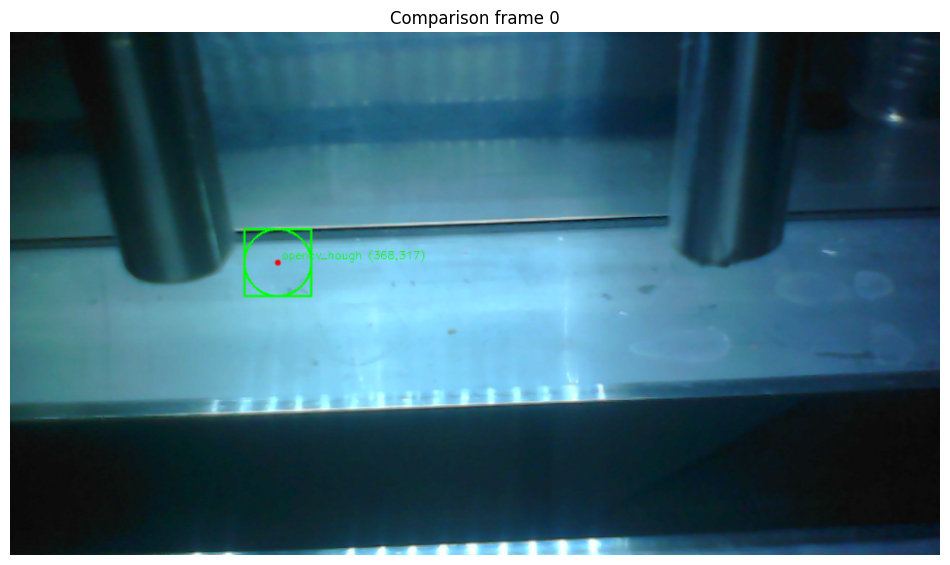

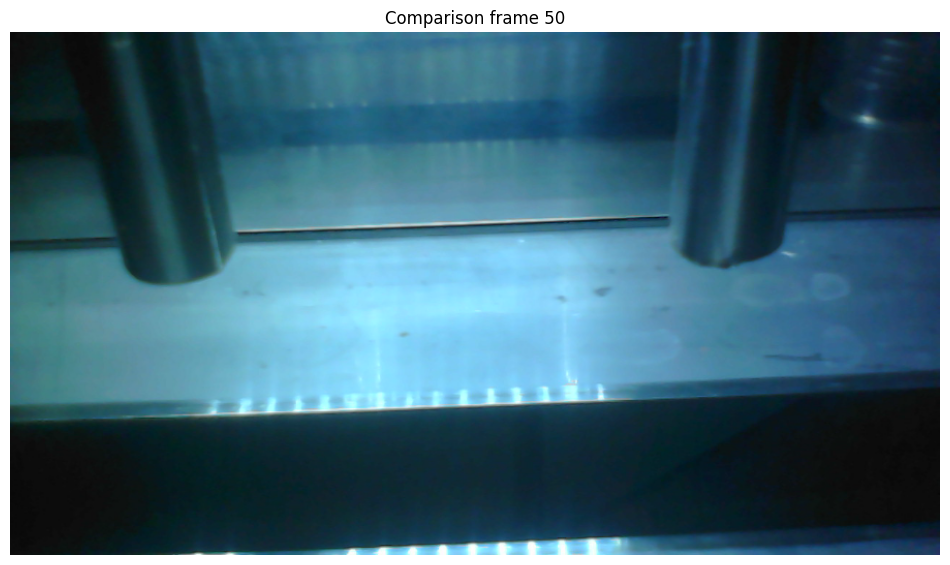

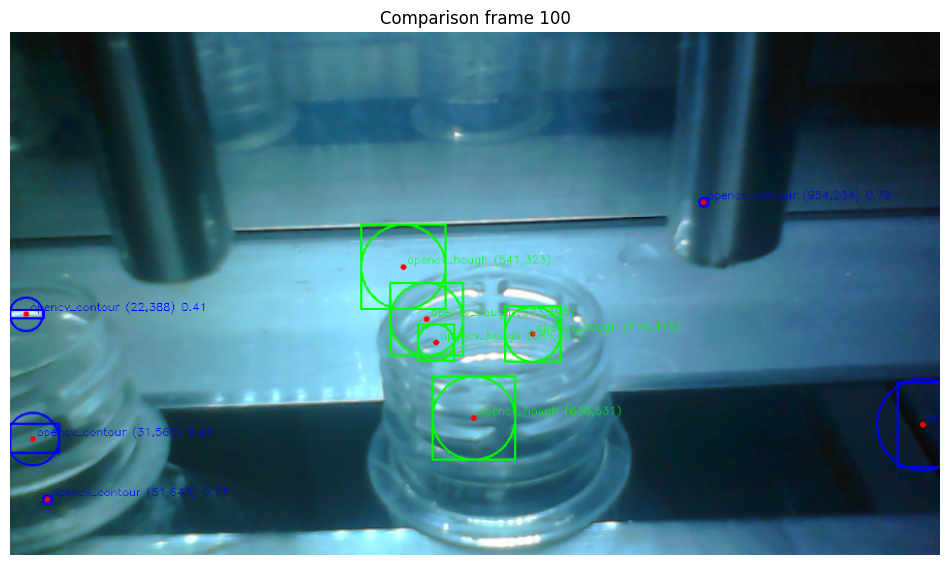

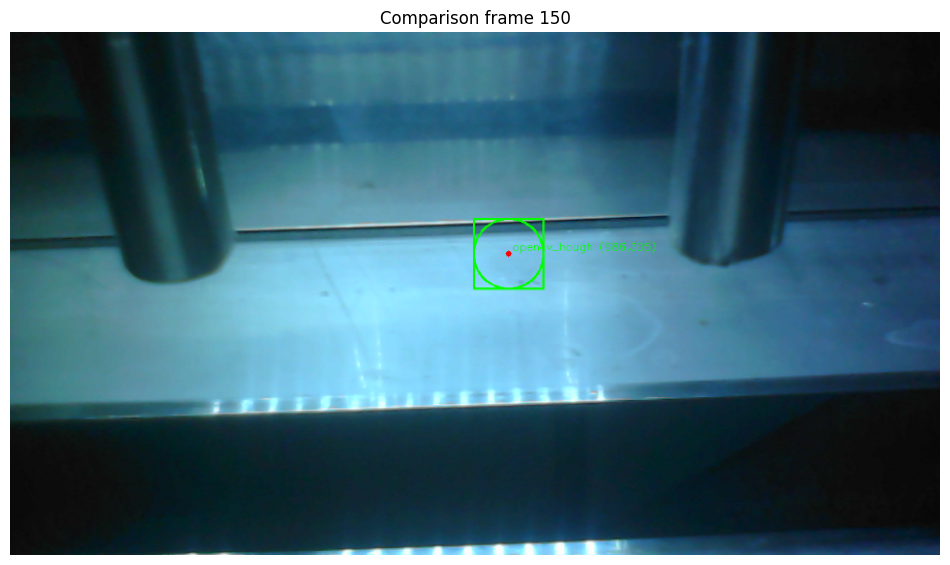

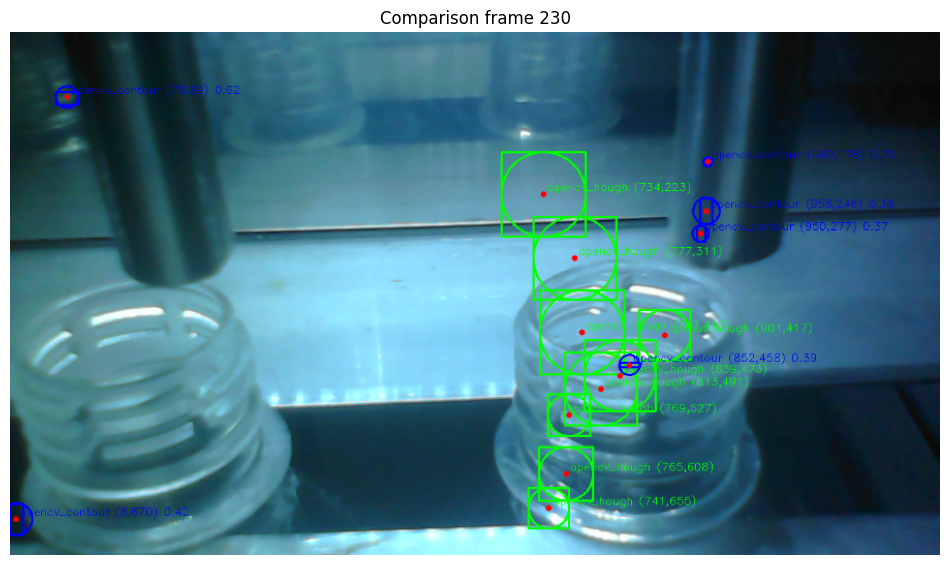

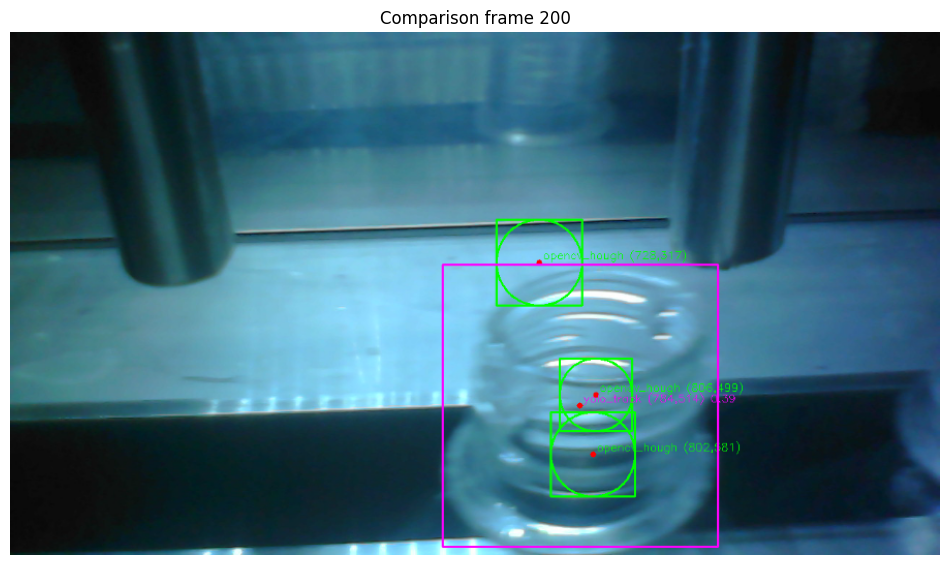

In [20]:
PREVIEW_FRAMES = [0, 50, 100, 150, 230,200]
PREVIEW_DIR = OUTPUT_DIR / "previews"
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

METHOD_COLORS = {
    "opencv_hough": (0, 255, 0),
    "opencv_contour": (255, 0, 0),
    "opencv_template": (0, 255, 255),
    "yolo_track": (255, 0, 255),
    "mediapipe_detector": (255, 255, 0),
}

if VIDEO_PATH.exists() and all_results:
    for frame_id in PREVIEW_FRAMES:
        frame = get_frame_by_index(VIDEO_PATH, frame_id)
        if frame is None:
            continue

        overlay = frame.copy()

        for method_name, df_method in all_results.items():
            if df_method.empty:
                continue

            det_rows = df_method[df_method["frame"] == frame_id].to_dict("records")
            overlay = draw_detections(
                overlay,
                det_rows,
                color=METHOD_COLORS.get(method_name, (0, 255, 0)),
                label_prefix=method_name + " "
            )

        out_path = PREVIEW_DIR / f"comparison_frame_{frame_id}.jpg"
        cv2.imwrite(str(out_path), overlay)
        show_frame(overlay, title=f"Comparison frame {frame_id}")
else:
    print("Run the detection methods first.")

# 8. Optional ground-truth evaluation

Create:

```text
data/ground_truth.csv
```

Minimum format:

```csv
frame,x_center,y_center
0,421,188
1,422,189
```

The evaluation matches predicted center points to ground truth using `MATCH_DISTANCE_PX`.

In [14]:
def load_ground_truth(path: Path):
    if not path.exists():
        print(f"No ground truth file found: {path}")
        return None

    gt = pd.read_csv(path)
    required = {"frame", "x_center", "y_center"}
    missing = required - set(gt.columns)
    if missing:
        raise ValueError(f"Ground truth is missing columns: {missing}")

    gt = gt.copy()
    gt["frame"] = gt["frame"].astype(int)
    return gt


def evaluate_center_points(pred_df, gt_df, distance_px=25):
    if pred_df is None or pred_df.empty:
        return {
            "true_positive": 0,
            "false_positive": 0,
            "false_negative": len(gt_df),
            "precision": 0,
            "recall": 0,
            "f1": 0,
            "mean_match_distance_px": np.nan,
        }

    tp = 0
    fp = 0
    fn = 0
    match_distances = []

    frames = sorted(set(gt_df["frame"]).union(set(pred_df["frame"])))

    for frame_id in frames:
        gt_frame = gt_df[gt_df["frame"] == frame_id][["x_center", "y_center"]].to_numpy(float)
        pred_frame = pred_df[pred_df["frame"] == frame_id][["x_center", "y_center"]].to_numpy(float)

        if len(gt_frame) == 0:
            fp += len(pred_frame)
            continue

        if len(pred_frame) == 0:
            fn += len(gt_frame)
            continue

        used_pred = set()

        for gt_point in gt_frame:
            distances = np.linalg.norm(pred_frame - gt_point, axis=1)
            order = np.argsort(distances)

            matched = False
            for pred_idx in order:
                if pred_idx in used_pred:
                    continue
                if distances[pred_idx] <= distance_px:
                    tp += 1
                    used_pred.add(pred_idx)
                    match_distances.append(float(distances[pred_idx]))
                    matched = True
                    break

            if not matched:
                fn += 1

        fp += len(pred_frame) - len(used_pred)

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    return {
        "true_positive": tp,
        "false_positive": fp,
        "false_negative": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_match_distance_px": np.mean(match_distances) if match_distances else np.nan,
    }


gt_df = load_ground_truth(GROUND_TRUTH_CSV)

if gt_df is not None and all_results:
    eval_rows = []

    for method_name, df_method in all_results.items():
        metrics = evaluate_center_points(df_method, gt_df, distance_px=MATCH_DISTANCE_PX)
        metrics["method"] = method_name
        eval_rows.append(metrics)

    eval_df = pd.DataFrame(eval_rows)
    eval_df = eval_df[[
        "method",
        "true_positive",
        "false_positive",
        "false_negative",
        "precision",
        "recall",
        "f1",
        "mean_match_distance_px",
    ]]

    eval_df.to_csv(OUTPUT_DIR / "method_accuracy_summary.csv", index=False)
    display(eval_df)
else:
    print("Ground-truth evaluation skipped.")

No ground truth file found: ..\data\ground_truth.csv
Ground-truth evaluation skipped.


# 9. Comparison plots

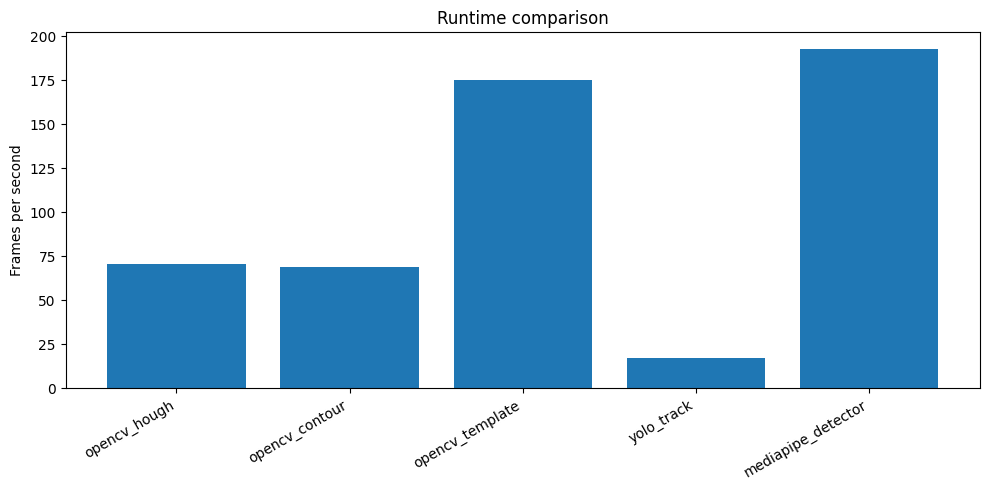

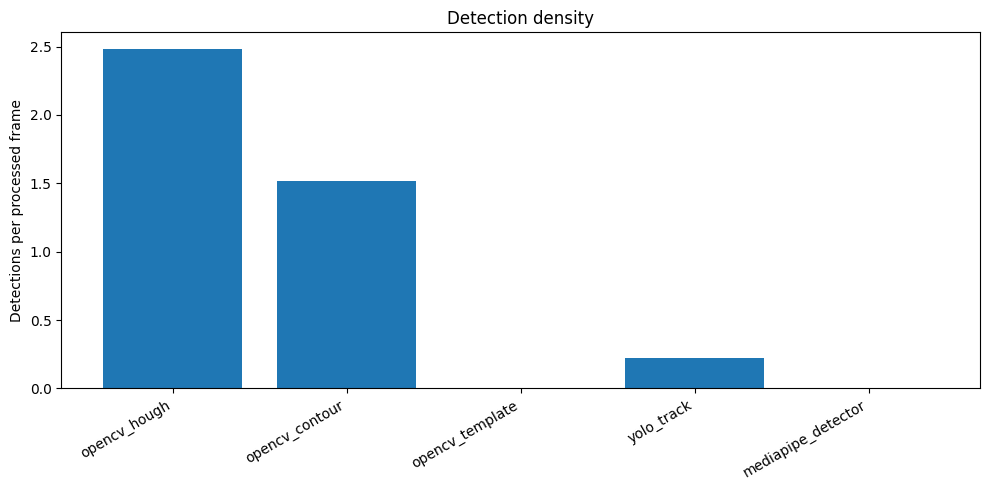

In [15]:
def plot_bar(df, x_col, y_col, title, ylabel):
    if df is None or df.empty or y_col not in df.columns:
        print(f"Cannot plot {y_col}")
        return

    plt.figure(figsize=(10, 5))
    plt.bar(df[x_col], df[y_col])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


if "summary_df" in globals() and len(summary_df):
    plot_bar(summary_df, "method", "fps", "Runtime comparison", "Frames per second")
    plot_bar(summary_df, "method", "detections_per_frame", "Detection density", "Detections per processed frame")

if "eval_df" in globals() and gt_df is not None:
    plot_bar(eval_df, "method", "precision", "Precision comparison", "Precision")
    plot_bar(eval_df, "method", "recall", "Recall comparison", "Recall")
    plot_bar(eval_df, "method", "f1", "F1 comparison", "F1 score")

# 10. Export combined CSV

In [16]:
if all_results:
    combined_df = pd.concat(all_results.values(), ignore_index=True)
    combined_path = OUTPUT_DIR / "all_method_detections.csv"
    combined_df.to_csv(combined_path, index=False)

    print("Saved:", combined_path)
    display(combined_df.head())
else:
    print("No results to combine.")

Saved: ..\outputs\all_method_detections.csv


,method,frame,time_sec,track_id,class_id,class_name,x_center,y_center,radius,x1,y1,x2,y2,confidence
0,opencv_hough,0,0.000000,-1,0,bottle_mouth_candidate,368.0,317.0,46.0,322.0,271.0,414.0,363.0,NaN
1,opencv_hough,4,0.133333,-1,0,bottle_mouth_candidate,320.0,487.0,43.0,277.0,444.0,363.0,530.0,NaN
2,opencv_hough,7,0.233333,-1,0,bottle_mouth_candidate,395.0,469.0,55.0,340.0,414.0,450.0,524.0,NaN
3,opencv_hough,15,0.499999,-1,0,bottle_mouth_candidate,298.0,511.0,19.0,279.0,492.0,317.0,530.0,NaN
4,opencv_hough,15,0.499999,-1,0,bottle_mouth_candidate,761.0,299.0,46.0,715.0,253.0,807.0,345.0,NaN


# 11. Extract training frames for your custom bottle-mouth model

Use this section to create images for labeling.

After extraction, label only the **bottle mouth / head without cap** using a bounding box.

Recommended class name:

```text
bottle_mouth
```

In [19]:
def extract_frames_for_labeling(
    video_path: Path,
    output_dir: Path = DATA_DIR / "frames_for_labeling",
    every_n_frames: int = 20,
    max_saved: int = 300,
):
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")

    frame_idx = 0
    saved = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % every_n_frames == 0:
            out_path = output_dir / f"frame_{saved:05d}.jpg"
            cv2.imwrite(str(out_path), frame)
            saved += 1

            if max_saved is not None and saved >= max_saved:
                break

        frame_idx += 1

    cap.release()
    print(f"Saved {saved} frames to {output_dir}")


# Uncomment this line when you are ready to extract frames for labeling:
extract_frames_for_labeling(VIDEO_PATH, every_n_frames=20, max_saved=300)

Saved 27 frames to ..\data\frames_for_labeling


# 12. Train custom YOLO model after labeling

After labeling, your dataset should look like this:

```text
dataset/
  images/
    train/
    val/
  labels/
    train/
    val/
  bottle_mouth.yaml
```

Example `bottle_mouth.yaml`:

```yaml
path: dataset
train: images/train
val: images/val

names:
  0: bottle_mouth
```

Then run the training cell below.

In [ ]:
def train_custom_yolo_bottle_mouth(
    data_yaml: str = "dataset/bottle_mouth.yaml",
    base_model: str = YOLO_PRETRAINED_MODEL_NAME,
    epochs: int = 100,
    imgsz: int = 640,
    batch: int = 8,
):
    try:
        from ultralytics import YOLO
    except ImportError as exc:
        raise ImportError("Install ultralytics first: pip install ultralytics") from exc

    model = YOLO(base_model)

    results = model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
    )

    best_pt = Path("runs/detect/train/weights/best.pt")
    if best_pt.exists():
        shutil.copy2(best_pt, YOLO_CUSTOM_BOTTLE_MOUTH_PATH)
        print(f"Copied best model to: {YOLO_CUSTOM_BOTTLE_MOUTH_PATH}")
    else:
        print("Training finished, but best.pt was not found at expected path.")
        print("Check runs/detect/train*/weights/best.pt")

    return results


# Uncomment after your dataset is ready:
# train_custom_yolo_bottle_mouth(
#     data_yaml="dataset/bottle_mouth.yaml",
#     base_model=YOLO_PRETRAINED_MODEL_NAME,
#     epochs=100,
#     imgsz=640,
#     batch=8,
# )

# Final recommendation

For your real video where bottles have **no cap**, use this workflow:

```text
1. Extract frames from video
2. Label the bottle mouth/head only
3. Train custom YOLO with class: bottle_mouth
4. Copy best.pt to models/yolo_bottle_mouth.pt
5. Run this notebook and export center pixel coordinates
```

OpenCV methods are useful for comparison, but the custom YOLO model will usually be the most reliable.